# Phase 1 — Baseline Comparison (BM25 vs Dense)
This notebook loads both run files (BM25 & Dense), computes metrics, and shows a small comparison table/plot.

> Matches SOP Step 5 output: baseline evaluation table & plots.

In [ ]:
# Optional: install
# !pip install -r requirements.txt

Model, nDCG@10, MRR@10
BM25, 0.8551, 0.8137
Dense, 0.8756, 0.8725


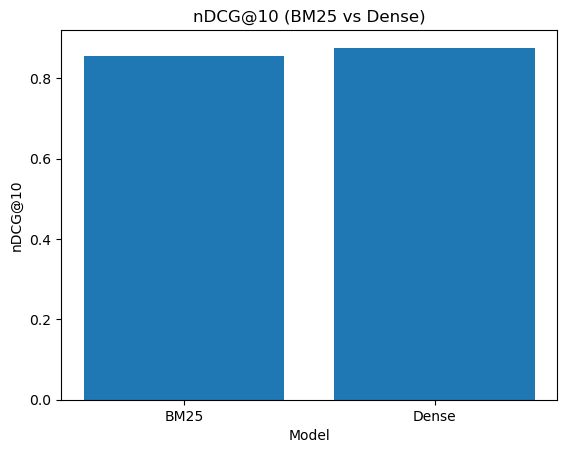

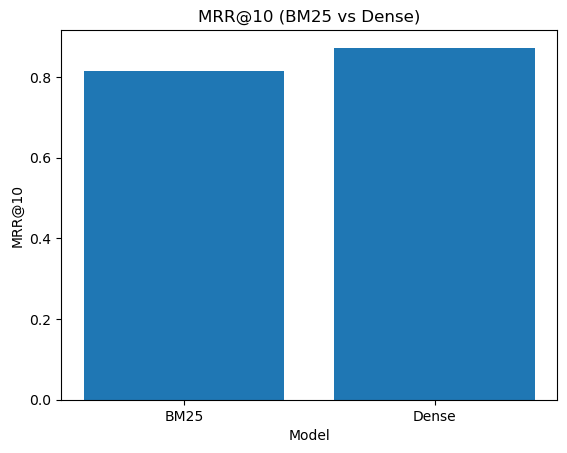

In [1]:
from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, List, Tuple
import numpy as np
import matplotlib.pyplot as plt

WORK_DIR = Path("./work")
SUBSET_DIR = WORK_DIR / "subsets" / "beir_trec-covid" / "subset_1"
BM25_RUN = SUBSET_DIR / "run_bm25.trec"
DENSE_RUN = SUBSET_DIR / "run_dense.trec"

def read_jsonl(path: Path):
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            yield json.loads(line)

def read_run(path: Path) -> Dict[str, List[Tuple[str, float]]]:
    per_q = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6: 
                continue
            qid, _, docid, _, score, _sys = parts[:6]
            per_q.setdefault(qid, []).append((docid, float(score)))
    for qid in per_q:
        per_q[qid].sort(key=lambda x: x[1], reverse=True)
    return per_q

qrels = {}
for r in read_jsonl(SUBSET_DIR / "qrels.jsonl"):
    qrels.setdefault(str(r["qid"]), {})[str(r["doc_id"])] = int(r["rel"])

def mrr_at_k(run, qrels, k=10):
    mrrs = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        rr = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                rr = 1.0 / i
                break
        mrrs.append(rr)
    return float(np.mean(mrrs)) if mrrs else 0.0

def ndcg_at_k(run, qrels, k=10):
    import math
    def dcg(rels): return sum((rel / math.log2(i + 2)) for i, rel in enumerate(rels))
    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        v = (dcg(rels)/idcg) if idcg > 0 else 0.0
        vals.append(v)
    return float(np.mean(vals)) if vals else 0.0

runs = {}
if BM25_RUN.exists():
    runs["BM25"] = read_run(BM25_RUN)
if DENSE_RUN.exists():
    runs["Dense"] = read_run(DENSE_RUN)

rows = []
for name, r in runs.items():
    rows.append((name, ndcg_at_k(r, qrels, 10), mrr_at_k(r, qrels, 10)))

print("Model, nDCG@10, MRR@10")
for name, nd, mr in rows:
    print(f"{name}, {nd:.4f}, {mr:.4f}")

# Simple bar plot
if rows:
    labels = [r[0] for r in rows]
    nd = [r[1] for r in rows]
    mr = [r[2] for r in rows]

    # Plot nDCG@10
    plt.figure()
    plt.bar(labels, nd)
    plt.title("nDCG@10 (BM25 vs Dense)")
    plt.xlabel("Model"); plt.ylabel("nDCG@10")
    plt.show()

    # Plot MRR@10
    plt.figure()
    plt.bar(labels, mr)
    plt.title("MRR@10 (BM25 vs Dense)")
    plt.xlabel("Model"); plt.ylabel("MRR@10")
    plt.show()
else:
    print("No run files found. Please run Notebooks 3 and 4 first.")

Model, nDCG@10, MRR@10
BM25, 0.9262, 0.9265
Dense, 0.8551, 0.8333


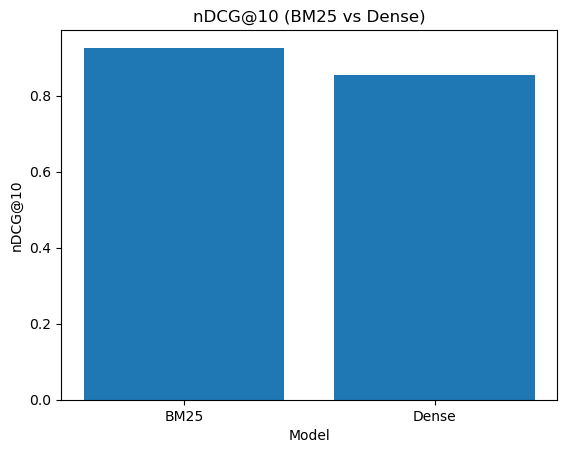

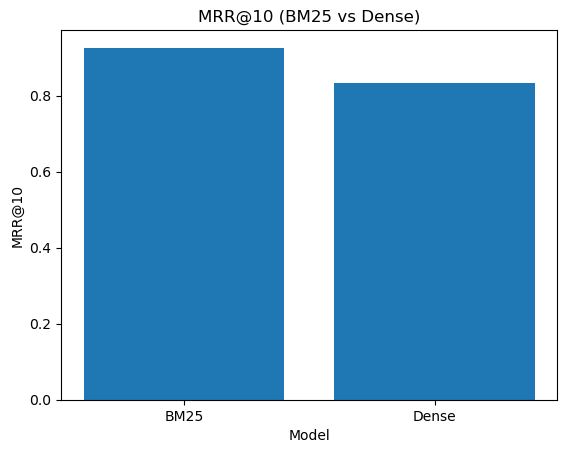

In [2]:
from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, List, Tuple
import numpy as np
import matplotlib.pyplot as plt

WORK_DIR = Path("./work")
SUBSET_DIR = WORK_DIR / "subsets" / "beir_trec-covid" / "subset_2"
BM25_RUN = SUBSET_DIR / "run_bm25.trec"
DENSE_RUN = SUBSET_DIR / "run_dense.trec"

def read_jsonl(path: Path):
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            yield json.loads(line)

def read_run(path: Path) -> Dict[str, List[Tuple[str, float]]]:
    per_q = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6: 
                continue
            qid, _, docid, _, score, _sys = parts[:6]
            per_q.setdefault(qid, []).append((docid, float(score)))
    for qid in per_q:
        per_q[qid].sort(key=lambda x: x[1], reverse=True)
    return per_q

qrels = {}
for r in read_jsonl(SUBSET_DIR / "qrels.jsonl"):
    qrels.setdefault(str(r["qid"]), {})[str(r["doc_id"])] = int(r["rel"])

def mrr_at_k(run, qrels, k=10):
    mrrs = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        rr = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                rr = 1.0 / i
                break
        mrrs.append(rr)
    return float(np.mean(mrrs)) if mrrs else 0.0

def ndcg_at_k(run, qrels, k=10):
    import math
    def dcg(rels): return sum((rel / math.log2(i + 2)) for i, rel in enumerate(rels))
    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        v = (dcg(rels)/idcg) if idcg > 0 else 0.0
        vals.append(v)
    return float(np.mean(vals)) if vals else 0.0

runs = {}
if BM25_RUN.exists():
    runs["BM25"] = read_run(BM25_RUN)
if DENSE_RUN.exists():
    runs["Dense"] = read_run(DENSE_RUN)

rows = []
for name, r in runs.items():
    rows.append((name, ndcg_at_k(r, qrels, 10), mrr_at_k(r, qrels, 10)))

print("Model, nDCG@10, MRR@10")
for name, nd, mr in rows:
    print(f"{name}, {nd:.4f}, {mr:.4f}")

# Simple bar plot
if rows:
    labels = [r[0] for r in rows]
    nd = [r[1] for r in rows]
    mr = [r[2] for r in rows]

    # Plot nDCG@10
    plt.figure()
    plt.bar(labels, nd)
    plt.title("nDCG@10 (BM25 vs Dense)")
    plt.xlabel("Model"); plt.ylabel("nDCG@10")
    plt.show()

    # Plot MRR@10
    plt.figure()
    plt.bar(labels, mr)
    plt.title("MRR@10 (BM25 vs Dense)")
    plt.xlabel("Model"); plt.ylabel("MRR@10")
    plt.show()
else:
    print("No run files found. Please run Notebooks 3 and 4 first.")

Model, nDCG@10, MRR@10
BM25, 0.9092, 0.8750
Dense, 0.8475, 0.8385


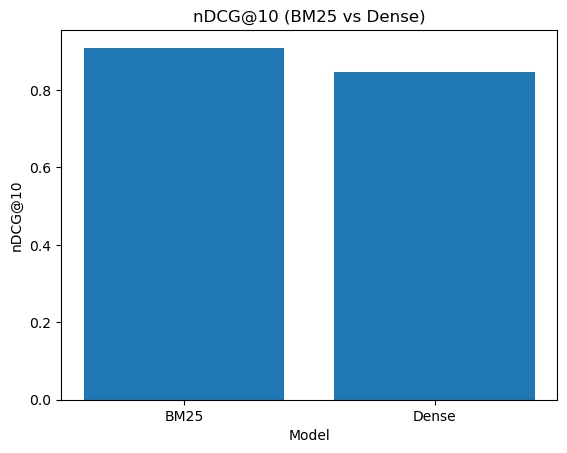

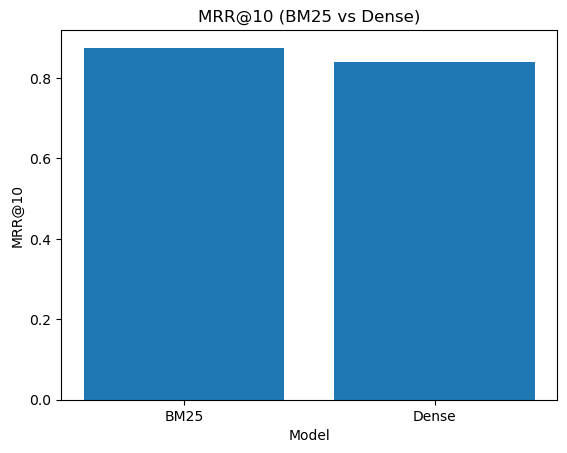

In [3]:
from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, List, Tuple
import numpy as np
import matplotlib.pyplot as plt

WORK_DIR = Path("./work")
SUBSET_DIR = WORK_DIR / "subsets" / "beir_trec-covid" / "subset_3"
BM25_RUN = SUBSET_DIR / "run_bm25.trec"
DENSE_RUN = SUBSET_DIR / "run_dense.trec"

def read_jsonl(path: Path):
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            yield json.loads(line)

def read_run(path: Path) -> Dict[str, List[Tuple[str, float]]]:
    per_q = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6: 
                continue
            qid, _, docid, _, score, _sys = parts[:6]
            per_q.setdefault(qid, []).append((docid, float(score)))
    for qid in per_q:
        per_q[qid].sort(key=lambda x: x[1], reverse=True)
    return per_q

qrels = {}
for r in read_jsonl(SUBSET_DIR / "qrels.jsonl"):
    qrels.setdefault(str(r["qid"]), {})[str(r["doc_id"])] = int(r["rel"])

def mrr_at_k(run, qrels, k=10):
    mrrs = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        rr = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                rr = 1.0 / i
                break
        mrrs.append(rr)
    return float(np.mean(mrrs)) if mrrs else 0.0

def ndcg_at_k(run, qrels, k=10):
    import math
    def dcg(rels): return sum((rel / math.log2(i + 2)) for i, rel in enumerate(rels))
    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        v = (dcg(rels)/idcg) if idcg > 0 else 0.0
        vals.append(v)
    return float(np.mean(vals)) if vals else 0.0

runs = {}
if BM25_RUN.exists():
    runs["BM25"] = read_run(BM25_RUN)
if DENSE_RUN.exists():
    runs["Dense"] = read_run(DENSE_RUN)

rows = []
for name, r in runs.items():
    rows.append((name, ndcg_at_k(r, qrels, 10), mrr_at_k(r, qrels, 10)))

print("Model, nDCG@10, MRR@10")
for name, nd, mr in rows:
    print(f"{name}, {nd:.4f}, {mr:.4f}")

# Simple bar plot
if rows:
    labels = [r[0] for r in rows]
    nd = [r[1] for r in rows]
    mr = [r[2] for r in rows]

    # Plot nDCG@10
    plt.figure()
    plt.bar(labels, nd)
    plt.title("nDCG@10 (BM25 vs Dense)")
    plt.xlabel("Model"); plt.ylabel("nDCG@10")
    plt.show()

    # Plot MRR@10
    plt.figure()
    plt.bar(labels, mr)
    plt.title("MRR@10 (BM25 vs Dense)")
    plt.xlabel("Model"); plt.ylabel("MRR@10")
    plt.show()
else:
    print("No run files found. Please run Notebooks 3 and 4 first.")